In [49]:
import pandas as pd
import numpy as np
import math

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

import random

from pymongo import MongoClient
import squic

In [50]:
# Set connection
client = MongoClient("mongodb://localhost:27017/")
db = client["bank"]
balances_collection = db["amlsim100"]

In [51]:
# Fetch balance evolution data from MongoDB
cursor = balances_collection.find({}, {"_id": 0})  # Exclude MongoDB item ID

balances = list(cursor)
balances

[{'date': 0,
  'balances': {'0': {'balance': 184.44},
   '1': {'balance': 175.8},
   '2': {'balance': 142.06},
   '3': {'balance': 125.89},
   '4': {'balance': 151.13},
   '5': {'balance': 140.49},
   '6': {'balance': 178.38},
   '7': {'balance': 130.33},
   '8': {'balance': 147.66},
   '9': {'balance': 158.34},
   '10': {'balance': 190.81},
   '11': {'balance': 150.47},
   '12': {'balance': 128.18},
   '13': {'balance': 197.39},
   '14': {'balance': 161.84},
   '15': {'balance': 125.05},
   '16': {'balance': 0.02},
   '17': {'balance': 198.28},
   '18': {'balance': 181.02},
   '19': {'balance': 255.77},
   '20': {'balance': 283.84},
   '21': {'balance': 345.97},
   '22': {'balance': 394.83},
   '23': {'balance': 336.8},
   '24': {'balance': 316.24},
   '25': {'balance': 307.5},
   '26': {'balance': 286.83},
   '27': {'balance': 322.18},
   '28': {'balance': 382.6},
   '29': {'balance': 0.02},
   '30': {'balance': 295.4},
   '31': {'balance': 401.48},
   '32': {'balance': 252.1},
   '3

In [52]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [53]:
#df

In [54]:
# Check the number of unique dates in extracted data
dates = [entry["date"] for entry in balances]
print("Unique dates found:", len(set(dates)))  # Should be 720
print("First 5 dates:", sorted(set(dates))[:5])
print("Last 5 dates:", sorted(set(dates))[-5:])

Unique dates found: 200
First 5 dates: [0, 1, 2, 3, 4]
Last 5 dates: [195, 196, 197, 198, 199]


In [55]:
df = pd.DataFrame([
    {key: value["balance"] for key, value in entry["balances"].items()} | {"date": entry["date"]}
    for entry in balances
])

# Convert "date" to datetime and set as index
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

In [56]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


In [57]:
df['1']

date
0       175.80
1         0.00
2        12.38
3        12.38
4        22.28
        ...   
195   -3998.92
196   -3998.92
197   -3998.92
198   -3998.92
199   -3986.54
Name: 1, Length: 200, dtype: float64

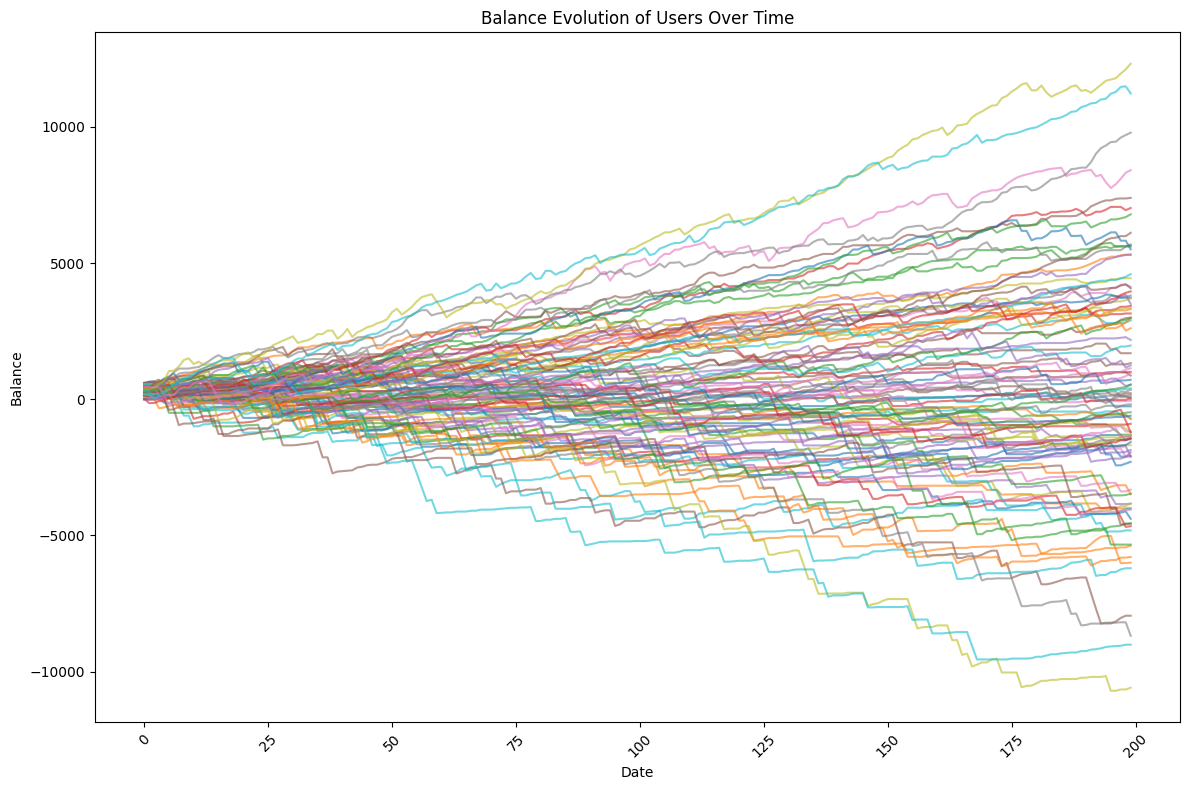

In [58]:
# Plot the balance evolution for all users (columns) as separate lines
plt.figure(figsize=(12, 8))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Date")
plt.ylabel("Balance")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

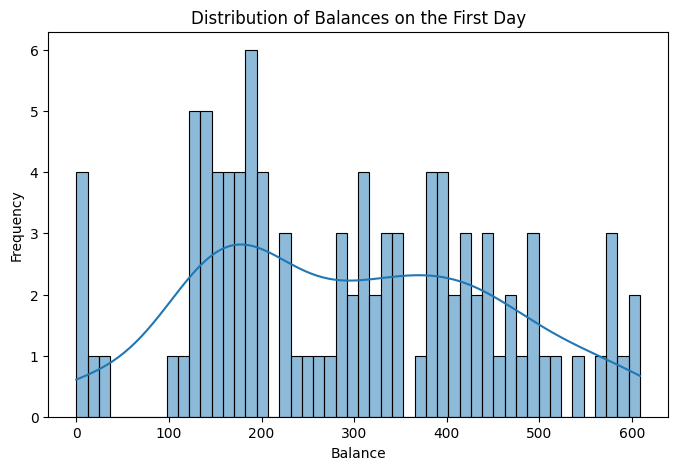

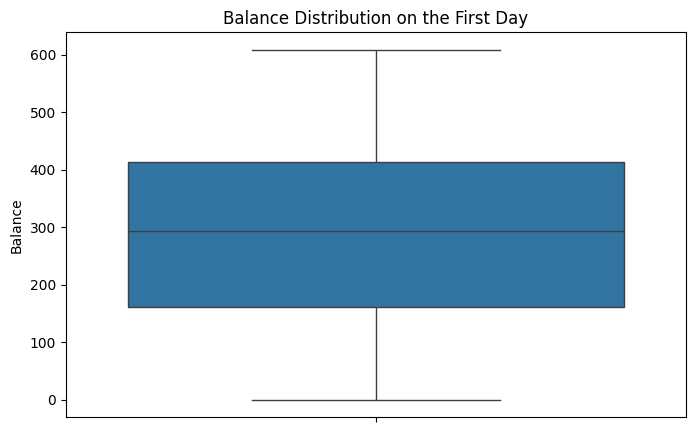

In [59]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

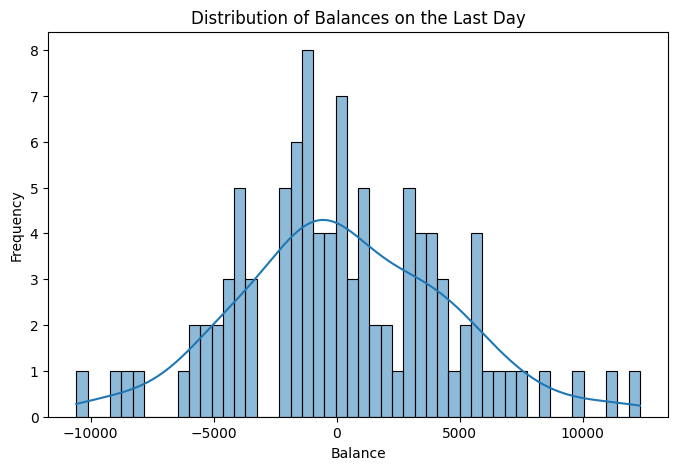

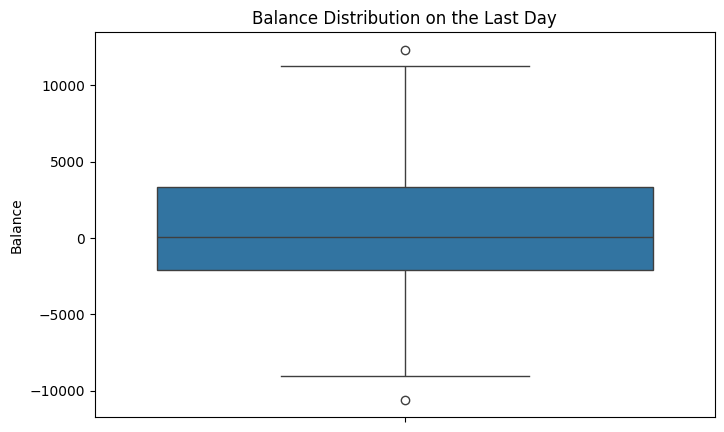

In [60]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

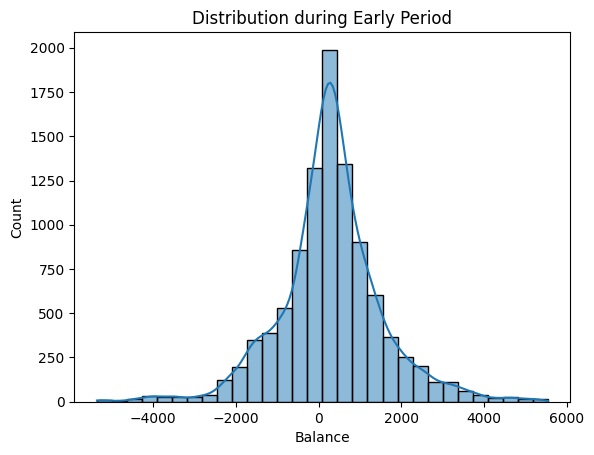

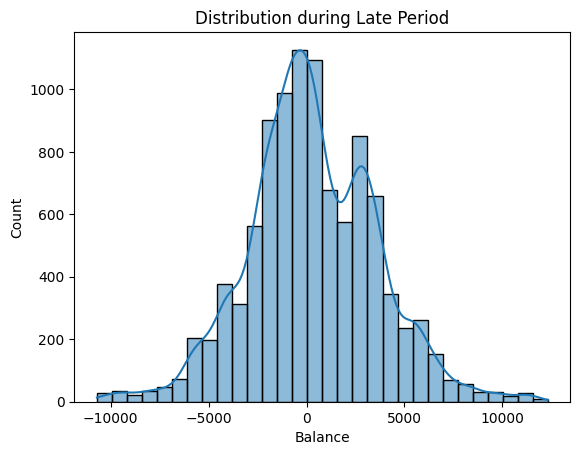

In [61]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

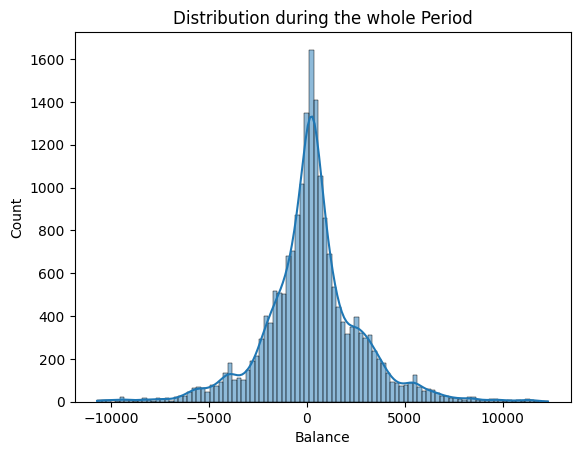

In [62]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

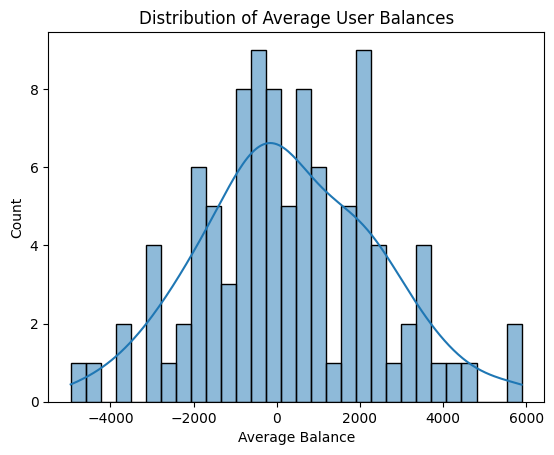

In [63]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [64]:
def compute_squic(df, l):
    Y = df.T.to_numpy()  # Transpose to get shape (users, days)

    [X,W,info_times,info_objective,info_logdetX,info_trSX] = squic.run(Y,l)

    print(X.todense())
    return X

def count_zero(X):
    # Count nonzero elements in X
    num_nonzero = X.nnz

    # Compute sparsity level
    total_elements = X.shape[0] * X.shape[1]
    sparsity = num_nonzero / total_elements

    print(f"Number of nonzero elements: {num_nonzero}")
    print(f"Sparsity level: {sparsity:.4f}")

def sparsity_pattern(X):
    plt.figure(figsize=(10, 10))
    plt.spy(X, markersize=5)  # Adjust markersize for better visibility
    plt.title("Sparsity Pattern of Precision Matrix (X)")
    plt.show()

In [65]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,253.63,322.82,322.82,322.82,322.82,374.37,374.37,374.37,...,-1450.41,-1450.41,-1381.22,-1312.03,-1312.03,-1312.03,-1312.03,-1312.03,-1496.47,-1427.28
1,175.80,0.00,12.38,12.38,22.28,22.28,32.18,32.18,32.18,32.18,...,-3823.12,-3823.12,-3823.12,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3986.54
2,142.06,142.06,142.06,142.06,198.79,56.74,66.64,66.64,-28.58,-28.58,...,-919.87,-919.87,-919.87,-919.87,-919.87,-1015.09,-1157.14,-1299.19,-1299.19,-1299.19
3,125.89,125.89,138.27,138.27,138.27,138.27,138.27,138.27,178.23,218.19,...,-989.31,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-897.73
4,151.13,182.79,195.17,195.17,283.92,204.50,204.50,204.50,204.50,236.16,...,638.77,687.49,687.49,687.49,687.49,759.18,759.18,639.73,488.62,532.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,411.81,411.81,578.08,647.27,702.29,738.97,738.97,839.29,855.04,870.79,...,5302.29,5467.55,5565.16,5685.16,5838.99,5914.94,5932.86,5990.27,5990.27,6112.25
96,437.84,452.90,452.90,452.90,165.99,159.13,159.13,369.29,433.40,433.40,...,8397.31,8426.50,8186.50,8237.63,7969.31,7758.35,7897.52,8095.31,8317.07,8411.27
97,238.28,238.28,307.47,406.85,637.58,807.53,997.13,1126.93,1126.93,1126.93,...,8504.86,8706.56,9016.88,9218.89,9317.82,9444.49,9457.70,9607.42,9701.23,9790.04
98,386.67,386.67,416.62,551.40,681.07,1032.70,1054.83,1201.22,1443.05,1505.01,...,11352.51,11255.45,11399.45,11549.06,11693.80,11741.15,11788.50,11959.72,12111.11,12321.77


In [73]:
l = [.4, 1e-1, 1e-2, 1e-3, 1e-4]

## Squic DF

In [74]:
rho_dict = {}

In [75]:
for rho in l:
    X_df = compute_squic(df, rho)
    rho_dict[rho] = X_df


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      4.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=9.73e-04 nnz(S)/p=1.00e+02
* iter=1 time=4.35e-03 obj=7.43e+07 |delta(obj)|/obj=1.37e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.04e+00] lns_iter=29 
* iter=2 time=3.08e-02 obj=2.96e+07 |delta(obj)|/obj=1.51e+00 nnz(X,L,W)/p=[1.00e+02 5.00e+01 6.29e+01] lns_iter=30 
* iter=3 time=2.44e-02 obj=1.77e+07 |delta(obj)|/

In [72]:
rho_dict

{0.1: <100x100 sparse matrix of type '<class 'numpy.float64'>'
 	with 10000 stored elements in Compressed Sparse Row format>,
 0.01: <100x100 sparse matrix of type '<class 'numpy.float64'>'
 	with 10000 stored elements in Compressed Sparse Row format>,
 0.001: <100x100 sparse matrix of type '<class 'numpy.float64'>'
 	with 10000 stored elements in Compressed Sparse Row format>,
 0.0001: <100x100 sparse matrix of type '<class 'numpy.float64'>'
 	with 10000 stored elements in Compressed Sparse Row format>}

In [77]:
for rho in l:
    X_df = rho_dict.get(rho)
    print(f"{count_zero(X_df)}")

Number of nonzero elements: 10000
Sparsity level: 1.0000
None
Number of nonzero elements: 10000
Sparsity level: 1.0000
None
Number of nonzero elements: 10000
Sparsity level: 1.0000
None
Number of nonzero elements: 10000
Sparsity level: 1.0000
None
Number of nonzero elements: 10000
Sparsity level: 1.0000
None


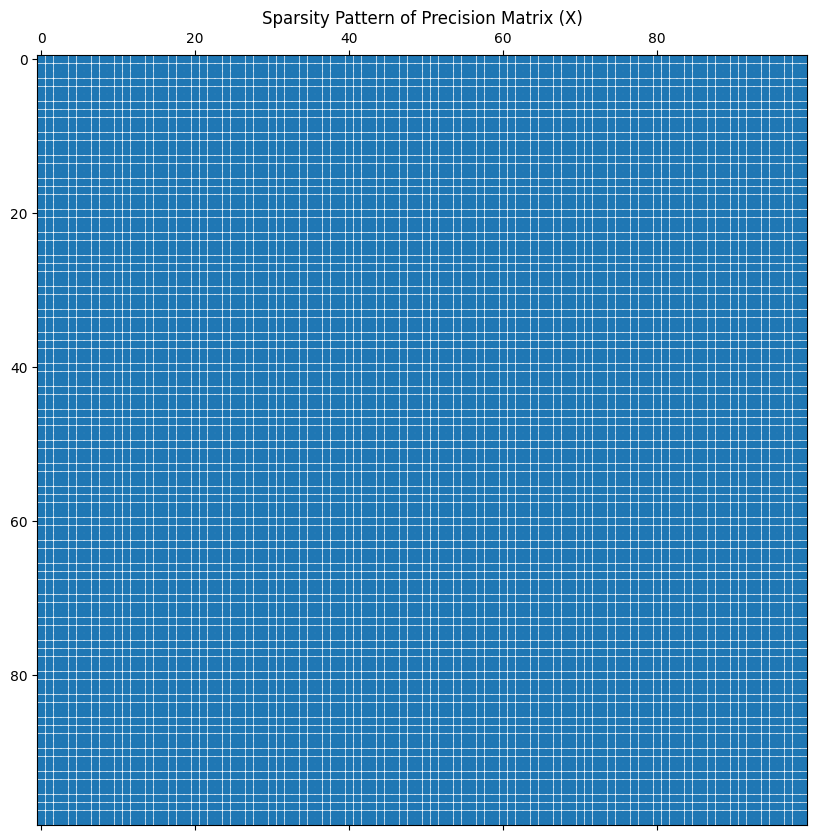

In [40]:
sparsity_pattern(X_df)